## Dependencies + Imports


In [1]:
!pip list

Package                 Version
----------------------- -----------
absl-py                 2.4.0
accelerate              1.13.0
affine                  2.4.0
albucore                0.0.24
albumentations          2.0.8
annotated-doc           0.0.4
annotated-types         0.7.0
anyio                   4.13.0
asttokens               3.0.1
astunparse              1.6.3
attrs                   25.4.0
audioop-lts             0.2.2
audioread               3.1.0
beautifulsoup4          4.14.3
blinker                 1.9.0
brotli                  1.2.0
bs4                     0.0.2
certifi                 2025.11.12
cffi                    2.0.0
charset-normalizer      3.4.7
click                   8.3.2
cligj                   0.7.2
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
et_xmlfile              2.0.0
executing               2.2.1
fastapi             

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import json
import tifffile as tiff
from skimage.transform import resize
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Add, Concatenate, Flatten
from tensorflow.keras.models import Model ,load_model
from tensorflow.keras.applications import ResNet50,  EfficientNetB0
import warnings
warnings.filterwarnings('ignore')


Avoid OOM ERRORS 

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

## 1_Load The Data


Constants

In [4]:
IMG_SIZE = (64, 64)
NUM_CLASSES = 10

CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

SPECTRAL_BANDS = [
    'Coastal Aerosol',  #Very short wavelength [coastlines-shallow water-atmospheric correction]
    'Blue',             #[haze-water-coastlinees]
    'Green',            #[vegie-foorest]
    'Red',              #Rare in agricultre and veggies(absorbed)
    'Red Edge 1',       #these 3 + the below one, can tell veggies changes and crops health
    'Red Edge 2',
    'Red Edge 3',
    'NIR',              #'near infra red 'Healthy plants reflect lots of NIR but Dead plants do not 
    'Red Edge 4',       # very close to NIR 
    'Water Vapor',      #[cloud-atmosphere condition]
    'SWIR Cirrus',      #[thin cirrus clouds]
    'SWIR 1',           #'Shortwave infrared 1 '[soil moisture-fires-burned areas] 
    'SWIR 2' ,          #[minerals-geology-drought-moisture]
    'NDVI'              # the 14's i added it
]

In [ ]:
DATA_ROOT = r"C:\college\CourseDataSci\final 2026\EuroSAT\allBands"

def load_satellite_data(dataset_dir, img_size=IMG_SIZE):

    data = []
    labels = []
    class_folders = sorted(os.listdir(dataset_dir))

    for class_name in class_folders:

        class_path = os.path.join(dataset_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            img_path = os.path.join(class_path, file_name)

            try:

                img = tiff.imread(img_path)

                if img.shape[-1] != 13:
                    print(f"Skipping {img_path}")
                    continue

                img = resize(
                    img,
                    (img_size[0], img_size[1], 13),
                    preserve_range=True,
                    anti_aliasing=True
                )

                # ← These two lines were missing
                data.append(img)
                labels.append(class_name)

            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    X = np.array(data)
    Y = np.array(labels)

    return X, Y

   
# Load data
# DATA_ROOT ="..EuroSATallBands"


X, Y = load_satellite_data(DATA_ROOT)

print(f"\n{len(X)} images loaded successfully.")
print(f"Data shape: {X.shape}")
print(f"Classes found: {sorted(CLASSES)}")



27597 images loaded successfully.
Data shape: (27597, 64, 64, 13)
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## NDVI


In [ ]:
## Normalized Difference Vegetation Index
RED_BAND = 3
NIR_BAND = 7

epsilon = 1e-6

red = X[:, :, :, RED_BAND]
nir = X[:, :, :, NIR_BAND]

ndvi = (nir - red) / (nir + red + epsilon)

# Add NDVI as the 14th channel
X = np.concatenate(
    [X, ndvi[..., np.newaxis]],
    axis=-1
)

print("Dataset shape after NDVI:", X.shape)

Dataset shape after NDVI: (27597, 64, 64, 14)


## MODELS

In [7]:
# to have y from strings (annualcrop, highway, etc..) to numbers (0,1,.....)
le = LabelEncoder()            
y_encoded = le.fit_transform(Y)
# from (0,1,2,3...) to [1,0,0,0...],[0,1,0,0,0....] by one-hot encoding
Y_onehot = to_categorical(y_encoded, num_classes=len(np.unique(Y)))

### Spliting DataSet

In [8]:
# Train + Temp (80% train, 20% temp)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y_onehot, test_size=0.2, random_state=42, stratify=Y_onehot
)
#Train + Temp (10% valid, 10% test)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)

print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 22077, Validation: 2760, Test: 2760


## NORMALIZATION

In [9]:
'''X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Mean and std computed ONLY from training set
mean = np.mean(X_train, axis=(0,1,2), keepdims=True)
std = np.std(X_train, axis=(0,1,2), keepdims=True)

std = np.where(std < 1e-6, 1.0, std)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Normalization complete.")'''

'X_train = X_train.astype(np.float32)\nX_val = X_val.astype(np.float32)\nX_test = X_test.astype(np.float32)\n\n# Mean and std computed ONLY from training set\nmean = np.mean(X_train, axis=(0,1,2), keepdims=True)\nstd = np.std(X_train, axis=(0,1,2), keepdims=True)\n\nstd = np.where(std < 1e-6, 1.0, std)\n\nX_train = (X_train - mean) / std\nX_val = (X_val - mean) / std\nX_test = (X_test - mean) / std\n\nprint("Normalization complete.")'

## Data Augmentation

Before training, we build a `tf.data` pipeline that applies random geometric augmentation (flips, rotation, zoom, translation) to the **training set only**. These transforms are purely spatial, so they work correctly even though our images have 13 spectral bands instead of the usual 3 (RGB). Augmentation helps the models generalize better and reduces overfitting, especially for the smaller/scratch-built architectures.


In [10]:
'''BATCH_SIZE = 16

# Keras preprocessing layers are purely spatial (flip/rotate/zoom/shift),
# so they apply cleanly to our 13-band images just like they would to RGB images.
data_augmentation = tf.keras.Sequential([


    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    

], name="augmentation")


def build_train_dataset(X, Y, batch_size=BATCH_SIZE, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.shuffle(buffer_size=len(X), seed=42)
    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_eval_dataset(X, Y, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Training data gets augmented; validation stays clean so it reflects real performance.
train_ds = build_train_dataset(X_train, Y_train, augment=True)
val_ds = build_eval_dataset(X_val, Y_val)

# Dictionary to keep a reference to every trained model so we can run Grad-CAM
# and compare them later without re-training.
trained_models = {}

print("train_ds and val_ds are ready (augmentation applied to training only).")
'''

'BATCH_SIZE = 16\n\n# Keras preprocessing layers are purely spatial (flip/rotate/zoom/shift),\n# so they apply cleanly to our 13-band images just like they would to RGB images.\ndata_augmentation = tf.keras.Sequential([\n\n\n    tf.keras.layers.RandomRotation(0.15),\n\n    tf.keras.layers.RandomZoom(\n        height_factor=0.10,\n        width_factor=0.10\n    ),\n\n    \n\n], name="augmentation")\n\n\ndef build_train_dataset(X, Y, batch_size=BATCH_SIZE, augment=True):\n    ds = tf.data.Dataset.from_tensor_slices((X, Y))\n    ds = ds.shuffle(buffer_size=len(X), seed=42)\n    if augment:\n        ds = ds.map(\n            lambda x, y: (data_augmentation(x, training=True), y),\n            num_parallel_calls=tf.data.AUTOTUNE\n        )\n    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)\n    return ds\n\n\ndef build_eval_dataset(X, Y, batch_size=BATCH_SIZE):\n    ds = tf.data.Dataset.from_tensor_slices((X, Y))\n    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)\n    return ds

## PRINCIPAL COMPONENT ANALYSIS (PCA)

In [11]:
# =============================================================================
# SECTION 5: PRINCIPAL COMPONENT ANALYSIS
# =============================================================================

from sklearn.decomposition import IncrementalPCA


SEED_VALUE = 42

# Flatten images
train_flat = X_train.reshape(len(X_train), -1)
val_flat   = X_val.reshape(len(X_val), -1)
test_flat  = X_test.reshape(len(X_test), -1)

print("Original flattened shape:", train_flat.shape)

N_COMPONENTS = 300
BATCH_SIZE = 512

ipca = IncrementalPCA(
    n_components=N_COMPONENTS,
    batch_size=BATCH_SIZE
)

print("\nFitting Incremental PCA...")

for i in range(0, train_flat.shape[0], BATCH_SIZE):
    ipca.partial_fit(train_flat[i:i+BATCH_SIZE])

print("Transforming training data...")

train_pca = []

for i in range(0, train_flat.shape[0], BATCH_SIZE):
    train_pca.append(
        ipca.transform(train_flat[i:i+BATCH_SIZE])
    )

train_pca = np.vstack(train_pca)

print("Transforming validation data...")
val_pca = ipca.transform(val_flat)

print("Transforming test data...")
test_pca = ipca.transform(test_flat)

print("\nDone!")

print("="*60)
print("PCA SUMMARY")
print("="*60)

print("Original train :", train_flat.shape)
print("Reduced train  :", train_pca.shape)

print("Original val   :", val_flat.shape)
print("Reduced val    :", val_pca.shape)

print("Original test  :", test_flat.shape)
print("Reduced test   :", test_pca.shape)

print(f"\nCompression Ratio : {train_flat.shape[1]/train_pca.shape[1]:.2f}x")
print(f"Explained Variance : {np.sum(ipca.explained_variance_ratio_):.2%}")

Original flattened shape: (22077, 57344)

Fitting Incremental PCA...


Transforming training data...
Transforming validation data...
Transforming test data...

Done!
PCA SUMMARY
Original train : (22077, 57344)
Reduced train  : (22077, 300)
Original val   : (2760, 57344)
Reduced val    : (2760, 300)
Original test  : (2760, 57344)
Reduced test   : (2760, 300)

Compression Ratio : 191.15x
Explained Variance : 97.11%


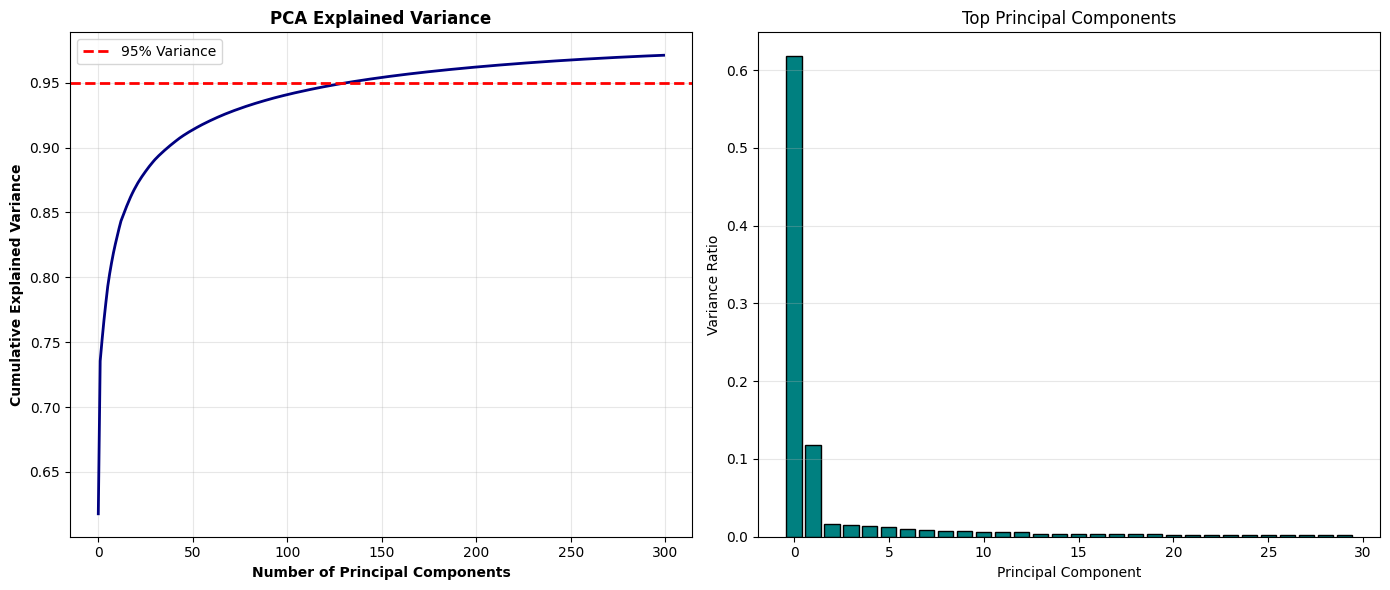

In [12]:
# =============================================================================
# PCA VARIANCE ANALYSIS
# =============================================================================

fig = plt.figure(figsize=(14,6))

# ------------------------
# Left plot
# ------------------------

ax1 = fig.add_subplot(1,2,1)

cumulative_variance = np.cumsum(
    ipca.explained_variance_ratio_
)

ax1.plot(
    cumulative_variance,
    linewidth=2,
    color="navy"
)

ax1.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    linewidth=2,
    label="95% Variance"
)

ax1.set_xlabel("Number of Principal Components", fontweight="bold")
ax1.set_ylabel("Cumulative Explained Variance", fontweight="bold")
ax1.set_title("PCA Explained Variance", fontweight="bold")
ax1.grid(alpha=0.3)
ax1.legend()

# ------------------------
# Right plot
# ------------------------

ax2 = fig.add_subplot(1,2,2)

num_display = min(
    30,
    len(ipca.explained_variance_ratio_)
)

ax2.bar(
    range(num_display),
    ipca.explained_variance_ratio_[:num_display],
    color="teal",
    edgecolor="black"
)

ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Variance Ratio")
ax2.set_title("Top Principal Components")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("PCA_ExplainedVariance.png", dpi=300)
plt.show()

In [13]:
'''# =============================================================================
# 2D PCA VISUALIZATION
# =============================================================================

print("Creating 2D PCA visualization...")

y_encoded = np.argmax(Y_train, axis=1)

pca_visual = IncrementalPCA(
    n_components=2,
    batch_size=256
)

train_pca_2d = pca_visual.fit_transform(train_flat)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    train_pca_2d[:,0],
    train_pca_2d[:,1],
    c=y_encoded,
    cmap="tab10",
    s=8,
    alpha=0.7
)

cbar = plt.colorbar(scatter)

cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASSES)

plt.xlabel("Principal Component 1", fontweight="bold")
plt.ylabel("Principal Component 2", fontweight="bold")
plt.title("2D PCA Projection of EuroSAT Dataset", fontweight="bold")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("PCA_2D_Visualization.png", dpi=300)

plt.show()

print("PCA visualization completed.")'''

'# =============================================================================\n# 2D PCA VISUALIZATION\n# =============================================================================\n\nprint("Creating 2D PCA visualization...")\n\ny_encoded = np.argmax(Y_train, axis=1)\n\npca_visual = IncrementalPCA(\n    n_components=2,\n    batch_size=256\n)\n\ntrain_pca_2d = pca_visual.fit_transform(train_flat)\n\nplt.figure(figsize=(10,8))\n\nscatter = plt.scatter(\n    train_pca_2d[:,0],\n    train_pca_2d[:,1],\n    c=y_encoded,\n    cmap="tab10",\n    s=8,\n    alpha=0.7\n)\n\ncbar = plt.colorbar(scatter)\n\ncbar.set_ticks(range(NUM_CLASSES))\ncbar.set_ticklabels(CLASSES)\n\nplt.xlabel("Principal Component 1", fontweight="bold")\nplt.ylabel("Principal Component 2", fontweight="bold")\nplt.title("2D PCA Projection of EuroSAT Dataset", fontweight="bold")\nplt.grid(alpha=0.2)\n\nplt.tight_layout()\nplt.savefig("PCA_2D_Visualization.png", dpi=300)\n\nplt.show()\n\nprint("PCA visualization complete

In [14]:
def predict_in_batches(keras_model, X, batch_size=16):
    """Predict in small manual chunks so we never hold a duplicate copy of the
    whole array in memory at once (avoids MemoryError on large test sets)."""
    preds = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i + batch_size]
        preds.append(keras_model.predict(batch, verbose=0))
    return np.concatenate(preds, axis=0)


# Collects Accuracy/Precision/Recall/F1 for every model so we can build one
# combined comparison table at the end instead of hardcoding numbers by hand.
model_metrics = {}


## Light weight CNN

In [15]:
'''def SpectrumNet_lite(input_shape=(64,64,13), num_classes=10):
    X_input = Input(input_shape)

    X = Conv2D(64, (1,1), strides=(2,2), padding='same')(X_input)

    def block(X, f):
        shortcut = X #to save the input
        X1 = Conv2D(f, (1,1), padding='same')(X)  #learnschannel
        X2 = Conv2D(f, (3,3), padding='same')(X)  #learns texture and neighbors
        X = Concatenate()([X1, X2])  #stack them
        X = BatchNormalization()(X)
        X = Activation("relu")(X) #not linear to learn cmplx
        if shortcut.shape[-1] == X.shape[-1]:
            X = Add()([shortcut, X])
        return X

    X = block(X, 32)
    X = MaxPooling2D((2,2))(X)
    X = block(X, 64)
    X = MaxPooling2D((2,2))(X)

    X = GlobalAveragePooling2D()(X) #averages each feature map into a single number ,reduce overfitting
    X = Dense(128, activation='relu')(X)# 128 neuron combine el extracted feature for prediction 
    X = Dropout(0.4)(X) #leave 40% out so u wont overfit
    X = Dense(num_classes, activation='softmax')(X) #here we use softmax

    return Model(inputs=X_input, outputs=X)

model = SpectrumNet_lite(input_shape=(64,64,13), num_classes=len(le.classes_))
model.summary()
'''

'def SpectrumNet_lite(input_shape=(64,64,13), num_classes=10):\n    X_input = Input(input_shape)\n\n    X = Conv2D(64, (1,1), strides=(2,2), padding=\'same\')(X_input)\n\n    def block(X, f):\n        shortcut = X #to save the input\n        X1 = Conv2D(f, (1,1), padding=\'same\')(X)  #learnschannel\n        X2 = Conv2D(f, (3,3), padding=\'same\')(X)  #learns texture and neighbors\n        X = Concatenate()([X1, X2])  #stack them\n        X = BatchNormalization()(X)\n        X = Activation("relu")(X) #not linear to learn cmplx\n        if shortcut.shape[-1] == X.shape[-1]:\n            X = Add()([shortcut, X])\n        return X\n\n    X = block(X, 32)\n    X = MaxPooling2D((2,2))(X)\n    X = block(X, 64)\n    X = MaxPooling2D((2,2))(X)\n\n    X = GlobalAveragePooling2D()(X) #averages each feature map into a single number ,reduce overfitting\n    X = Dense(128, activation=\'relu\')(X)# 128 neuron combine el extracted feature for prediction \n    X = Dropout(0.4)(X) #leave 40% out so u w

In [16]:
'''model = SpectrumNet_lite(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "SpectrumNet_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("SpectrumNet_final.h5")'''

'model = SpectrumNet_lite(\n    input_shape=(64,64,14),\n    num_classes=len(le.classes_)\n)\n\ncheckpoint = ModelCheckpoint(\n    "SpectrumNet_best.h5",\n    monitor="val_accuracy",\n    save_best_only=True,\n    mode="max",\n    verbose=1\n)\n\nearlystop = EarlyStopping(\n    monitor="val_loss",\n    patience=7,\n    restore_best_weights=True\n)\n\nmodel.compile(\n    optimizer="adam",\n    loss="categorical_crossentropy",\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    X_train,\n    Y_train,\n    validation_data=(X_val,Y_val),\n    epochs=40,\n    batch_size=16,\n    callbacks=[checkpoint,earlystop],\n    verbose=1\n)\n\nmodel.save("SpectrumNet_final.h5")'

In [17]:
'''pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(Y_test, axis=1)

acc_LightCNN = accuracy_score(y_true,y_pred)
precision_LightCNN = precision_score(y_true,y_pred,average="weighted")
recall_LightCNN = recall_score(y_true,y_pred,average="weighted")
f1_LightCNN = f1_score(y_true,y_pred,average="weighted")

print("SpectrumNet")
print("Accuracy :",acc_LightCNN)
print("Precision:",precision_LightCNN)
print("Recall :",recall_LightCNN)
print("F1 :",f1_LightCNN)

with open("SpectrumNet_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_LightCNN}\n")
    f.write(f"Precision: {precision_LightCNN}\n")
    f.write(f"Recall: {recall_LightCNN}\n")
    f.write(f"F1 Score: {f1_LightCNN}\n")'''

'pred = model.predict(X_test)\n\ny_pred = np.argmax(pred, axis=1)\ny_true = np.argmax(Y_test, axis=1)\n\nacc_LightCNN = accuracy_score(y_true,y_pred)\nprecision_LightCNN = precision_score(y_true,y_pred,average="weighted")\nrecall_LightCNN = recall_score(y_true,y_pred,average="weighted")\nf1_LightCNN = f1_score(y_true,y_pred,average="weighted")\n\nprint("SpectrumNet")\nprint("Accuracy :",acc_LightCNN)\nprint("Precision:",precision_LightCNN)\nprint("Recall :",recall_LightCNN)\nprint("F1 :",f1_LightCNN)\n\nwith open("SpectrumNet_metrics.txt","w") as f:\n    f.write(f"Accuracy: {acc_LightCNN}\n")\n    f.write(f"Precision: {precision_LightCNN}\n")\n    f.write(f"Recall: {recall_LightCNN}\n")\n    f.write(f"F1 Score: {f1_LightCNN}\n")'

## 2.Basic CNN

In [18]:
'''# 5 Conv layers-3 MaxPooling layers-Flatten-Dense-Softmax

def SimpleCNN(input_shape=(64,64,14), num_classes=10):

    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)

    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)

    x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

model_cnn=SimpleCNN(input_shape=(64,64,14), num_classes=len(le.classes_))'''

"# 5 Conv layers-3 MaxPooling layers-Flatten-Dense-Softmax\n\ndef SimpleCNN(input_shape=(64,64,14), num_classes=10):\n\n    inputs = Input(shape=input_shape)\n\n    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)\n    x = MaxPooling2D((2,2))(x)\n\n    x = Conv2D(64, (3,3), padding='same', activation='relu')(x)\n    x = MaxPooling2D((2,2))(x)\n\n    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)\n\n    x = Conv2D(128, (3,3), padding='same', activation='relu')(x)\n\n    x = Conv2D(256, (3,3), padding='same', activation='relu')(x)\n    x = MaxPooling2D((2,2))(x)\n\n    x = Flatten()(x)\n\n    x = Dense(256, activation='relu')(x)\n    x = Dropout(0.5)(x)\n\n    outputs = Dense(num_classes, activation='softmax')(x)\n\n    return Model(inputs, outputs)\n\nmodel_cnn=SimpleCNN(input_shape=(64,64,14), num_classes=len(le.classes_))"

In [19]:
'''model = SimpleCNN(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "SimpleCNN_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("SimpleCNN_final.h5")'''

'model = SimpleCNN(\n    input_shape=(64,64,14),\n    num_classes=len(le.classes_)\n)\n\ncheckpoint = ModelCheckpoint(\n    "SimpleCNN_best.h5",\n    monitor="val_accuracy",\n    save_best_only=True,\n    mode="max",\n    verbose=1\n)\n\nearlystop = EarlyStopping(\n    monitor="val_loss",\n    patience=7,\n    restore_best_weights=True\n)\n\nmodel.compile(\n    optimizer="adam",\n    loss="categorical_crossentropy",\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    X_train,\n    Y_train,\n    validation_data=(X_val,Y_val),\n    epochs=40,\n    batch_size=16,\n    callbacks=[checkpoint,earlystop],\n    verbose=1\n)\n\nmodel.save("SimpleCNN_final.h5")'

In [20]:
'''pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_CNN = accuracy_score(y_true,y_pred)
precision_CNN = precision_score(y_true,y_pred,average="weighted")
recall_CNN = recall_score(y_true,y_pred,average="weighted")
f1_CNN = f1_score(y_true,y_pred,average="weighted")

print("SimpleCNN")
print(acc_CNN,precision_CNN,recall_CNN,f1_CNN)

with open("SimpleCNN_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_CNN}\n")
    f.write(f"Precision: {precision_CNN}\n")
    f.write(f"Recall: {recall_CNN}\n")
    f.write(f"F1 Score: {f1_CNN}\n")'''

'pred = model.predict(X_test)\n\ny_pred = np.argmax(pred,axis=1)\ny_true = np.argmax(Y_test,axis=1)\n\nacc_CNN = accuracy_score(y_true,y_pred)\nprecision_CNN = precision_score(y_true,y_pred,average="weighted")\nrecall_CNN = recall_score(y_true,y_pred,average="weighted")\nf1_CNN = f1_score(y_true,y_pred,average="weighted")\n\nprint("SimpleCNN")\nprint(acc_CNN,precision_CNN,recall_CNN,f1_CNN)\n\nwith open("SimpleCNN_metrics.txt","w") as f:\n    f.write(f"Accuracy: {acc_CNN}\n")\n    f.write(f"Precision: {precision_CNN}\n")\n    f.write(f"Recall: {recall_CNN}\n")\n    f.write(f"F1 Score: {f1_CNN}\n")'

## 2.ResNet50

In [21]:
'''def ResNet50_Model(input_shape=(64,64,14), num_classes=10):

    base_model = ResNet50(
        include_top=False,
        weights=None,
        input_shape=input_shape
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(base_model.input, outputs)

    return model'''

"def ResNet50_Model(input_shape=(64,64,14), num_classes=10):\n\n    base_model = ResNet50(\n        include_top=False,\n        weights=None,\n        input_shape=input_shape\n    )\n\n    x = base_model.output\n    x = GlobalAveragePooling2D()(x)\n    x = Dense(256, activation='relu')(x)\n    x = Dropout(0.5)(x)\n\n    outputs = Dense(num_classes, activation='softmax')(x)\n\n    model = Model(base_model.input, outputs)\n\n    return model"

In [22]:
'''model = ResNet50_Model(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "ResNet50_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("ResNet50_final.h5")'''

'model = ResNet50_Model(\n    input_shape=(64,64,14),\n    num_classes=len(le.classes_)\n)\n\ncheckpoint = ModelCheckpoint(\n    "ResNet50_best.h5",\n    monitor="val_accuracy",\n    save_best_only=True,\n    mode="max",\n    verbose=1\n)\n\nearlystop = EarlyStopping(\n    monitor="val_loss",\n    patience=7,\n    restore_best_weights=True\n)\n\nmodel.compile(\n    optimizer="adam",\n    loss="categorical_crossentropy",\n    metrics=["accuracy"]\n)\n\nhistory = model.fit(\n    X_train,\n    Y_train,\n    validation_data=(X_val,Y_val),\n    epochs=40,\n    batch_size=16,\n    callbacks=[checkpoint,earlystop],\n    verbose=1\n)\n\nmodel.save("ResNet50_final.h5")'

In [23]:
'''pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_resN = accuracy_score(y_true,y_pred)
precision_resN = precision_score(y_true,y_pred,average="weighted")
recall_resN = recall_score(y_true,y_pred,average="weighted")
f1_resN = f1_score(y_true,y_pred,average="weighted")

print("ResNet50")
print(acc_resN,precision_resN,recall_resN,f1_resN)

with open("ResNet50_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_resN}\n")
    f.write(f"Precision: {precision_resN}\n")
    f.write(f"Recall: {recall_resN}\n")
    f.write(f"F1 Score: {f1_resN}\n")'''

'pred = model.predict(X_test)\n\ny_pred = np.argmax(pred,axis=1)\ny_true = np.argmax(Y_test,axis=1)\n\nacc_resN = accuracy_score(y_true,y_pred)\nprecision_resN = precision_score(y_true,y_pred,average="weighted")\nrecall_resN = recall_score(y_true,y_pred,average="weighted")\nf1_resN = f1_score(y_true,y_pred,average="weighted")\n\nprint("ResNet50")\nprint(acc_resN,precision_resN,recall_resN,f1_resN)\n\nwith open("ResNet50_metrics.txt","w") as f:\n    f.write(f"Accuracy: {acc_resN}\n")\n    f.write(f"Precision: {precision_resN}\n")\n    f.write(f"Recall: {recall_resN}\n")\n    f.write(f"F1 Score: {f1_resN}\n")'

## 3.EfficientNet

In [24]:
def EfficientNet_Model(input_shape=(64,64,14), num_classes=10):

    base_model = EfficientNetB0(
        include_top=False,
        weights=None,
        input_shape=input_shape
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(base_model.input, outputs)

    return model

In [25]:
model = EfficientNet_Model(
    input_shape=(64,64,14),
    num_classes=len(le.classes_)
)

checkpoint = ModelCheckpoint(
    "EfficientNet_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,
    batch_size=16,
    callbacks=[checkpoint,earlystop],
    verbose=1
)

model.save("EfficientNet_final.h5")

Epoch 1/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5055 - loss: 1.5103
Epoch 1: val_accuracy improved from None to 0.65217, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 254s 166ms/step - accuracy: 0.6039 - loss: 1.2138 - val_accuracy: 0.6522 - val_loss: 1.0318
Epoch 2/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7370 - loss: 0.8258
Epoch 2: val_accuracy improved from 0.65217 to 0.74022, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 224s 162ms/step - accuracy: 0.7613 - loss: 0.7653 - val_accuracy: 0.7402 - val_loss: 0.8645
Epoch 3/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7769 - loss: 0.6893
Epoch 3: val_accuracy improved from 0.74022 to 0.86957, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 218s 158ms/step - accuracy: 0.7835 - loss: 0.6696 - val_accuracy: 0.8696 - val_loss: 0.4087
Epoch 4/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7699 - loss: 0.6804
Epoch 4: val_accuracy did not improve from 0.86957
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.7654 - loss: 0.6970 - val_accuracy: 0.8192 - val_loss: 0.6866
Epoch 5/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8132 - loss: 0.6011
Epoch 5: val_accuracy did not improve from 0.86957
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 218s 158ms/step - accuracy: 0.8349 - loss: 0.5305 - val_accuracy: 0.8207 - val_loss: 0.5628
Epoch 6/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8444 - loss: 0.4965
Epoch 6: val_accuracy improved from 0.86957 to 0.87536, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.8245 - loss: 0.5592 - val_accuracy: 0.8754 - val_loss: 0.3994
Epoch 7/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.8342 - loss: 0.5229
Epoch 7: val_accuracy did not improve from 0.87536
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 227s 165ms/step - accuracy: 0.8305 - loss: 0.5291 - val_accuracy: 0.8594 - val_loss: 0.4276
Epoch 8/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8695 - loss: 0.4038
Epoch 8: val_accuracy improved from 0.87536 to 0.89928, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.8769 - loss: 0.3880 - val_accuracy: 0.8993 - val_loss: 0.3003
Epoch 9/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8890 - loss: 0.3561
Epoch 9: val_accuracy improved from 0.89928 to 0.92681, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 223s 162ms/step - accuracy: 0.8941 - loss: 0.3442 - val_accuracy: 0.9268 - val_loss: 0.2143
Epoch 10/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9105 - loss: 0.2949
Epoch 10: val_accuracy did not improve from 0.92681
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 227s 164ms/step - accuracy: 0.9095 - loss: 0.2940 - val_accuracy: 0.9054 - val_loss: 0.3233
Epoch 11/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9047 - loss: 0.3176
Epoch 11: val_accuracy did not improve from 0.92681
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 226s 164ms/step - accuracy: 0.9114 - loss: 0.2924 - val_accuracy: 0.9246 - val_loss: 0.2633
Epoch 12/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9238 - loss: 0.2449
Epoch 12: val_accuracy did not improve from 0.92681
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 224s 162ms/step - accuracy: 0.9232 - loss: 0.2459 - val_accuracy: 0.9101 - val_loss: 0.3020
Epoch 13/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9222 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9238 - loss: 0.2503 - val_accuracy: 0.9417 - val_loss: 0.1824
Epoch 14/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9359 - loss: 0.1962
Epoch 14: val_accuracy did not improve from 0.94167
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9348 - loss: 0.2026 - val_accuracy: 0.8870 - val_loss: 0.3482
Epoch 15/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9404 - loss: 0.1880
Epoch 15: val_accuracy did not improve from 0.94167
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 225s 163ms/step - accuracy: 0.9424 - loss: 0.1858 - val_accuracy: 0.9188 - val_loss: 0.2623
Epoch 16/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9443 - loss: 0.1840
Epoch 16: val_accuracy did not improve from 0.94167
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 225s 163ms/step - accuracy: 0.9443 - loss: 0.1812 - val_accuracy: 0.9301 - val_loss: 0.2054
Epoch 17/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9492 - l

1380/1380 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.9517 - loss: 0.1567 - val_accuracy: 0.9500 - val_loss: 0.1492
Epoch 19/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9569 - loss: 0.1366
Epoch 19: val_accuracy did not improve from 0.95000
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 265s 163ms/step - accuracy: 0.9526 - loss: 0.1525 - val_accuracy: 0.9304 - val_loss: 0.2309
Epoch 20/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9581 - loss: 0.1414
Epoch 20: val_accuracy improved from 0.95000 to 0.96159, saving model to EfficientNet_best.h5


1380/1380 ━━━━━━━━━━━━━━━━━━━━ 225s 163ms/step - accuracy: 0.9581 - loss: 0.1380 - val_accuracy: 0.9616 - val_loss: 0.1237
Epoch 21/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9612 - loss: 0.1233
Epoch 21: val_accuracy did not improve from 0.96159
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 224s 162ms/step - accuracy: 0.9609 - loss: 0.1214 - val_accuracy: 0.9438 - val_loss: 0.1880
Epoch 22/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9639 - loss: 0.1135
Epoch 22: val_accuracy did not improve from 0.96159
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 224s 162ms/step - accuracy: 0.9621 - loss: 0.1216 - val_accuracy: 0.9438 - val_loss: 0.1769
Epoch 23/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9697 - loss: 0.0947
Epoch 23: val_accuracy did not improve from 0.96159
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 223s 161ms/step - accuracy: 0.9674 - loss: 0.1072 - val_accuracy: 0.9399 - val_loss: 0.2094
Epoch 24/40
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9653 - l

In [26]:
pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
y_true = np.argmax(Y_test,axis=1)

acc_effN = accuracy_score(y_true,y_pred)
precision_effN = precision_score(y_true,y_pred,average="weighted")
recall_effN = recall_score(y_true,y_pred,average="weighted")
f1_effN = f1_score(y_true,y_pred,average="weighted")

print("EfficientNet")
print(acc_effN,precision_effN,recall_effN,f1_effN)

with open("EfficientNet_metrics.txt","w") as f:
    f.write(f"Accuracy: {acc_effN}\n")
    f.write(f"Precision: {precision_effN}\n")
    f.write(f"Recall: {recall_effN}\n")
    f.write(f"F1 Score: {f1_effN}\n")

87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step
EfficientNet
0.9557971014492753 0.9566196431869304 0.9557971014492753 0.9557525649290199


In [27]:
for f in sorted(os.listdir()):
    if f.endswith(".h5"):
        print(f)

EfficientNet_best.h5
EfficientNet_final.h5
ResNet50_best.h5
ResNet50_final.h5
SimpleCNN_best.h5
SimpleCNN_final.h5
SpectrumNet_best.h5
SpectrumNet_final.h5


# Compare 4 Models

In [28]:
MODEL_FOLDER = r"C:\college\CourseDataSci\final 2026\finally"

models = {
    "SpectrumNet": "SpectrumNet_final.h5",
    "SimpleCNN": "SimpleCNN_final.h5",
    "ResNet50": "ResNet50_final.h5",
    "EfficientNet": "EfficientNet_final.h5"
}

results = []

for model_name, model_path in models.items():

    print(f"Evaluating {model_name}...")

    full_path = os.path.join(MODEL_FOLDER, model_path)

    model = load_model(full_path)

    predictions = model.predict(X_test, verbose=0)

    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

comparison = pd.DataFrame(results)

print(comparison)

comparison.to_csv("Model_Comparison.csv", index=False)

print("Comparison saved as Model_Comparison.csv")

Evaluating SpectrumNet...


Evaluating SimpleCNN...
Evaluating ResNet50...


Evaluating EfficientNet...


          Model  Accuracy  Precision    Recall  F1 Score
0   SpectrumNet  0.930797   0.934693  0.930797  0.930036
1     SimpleCNN  0.882971   0.882059  0.882971  0.881520
2      ResNet50  0.949638   0.950693  0.949638  0.949605
3  EfficientNet  0.955797   0.956620  0.955797  0.955753
Comparison saved as Model_Comparison.csv


Evaluating SpectrumNet


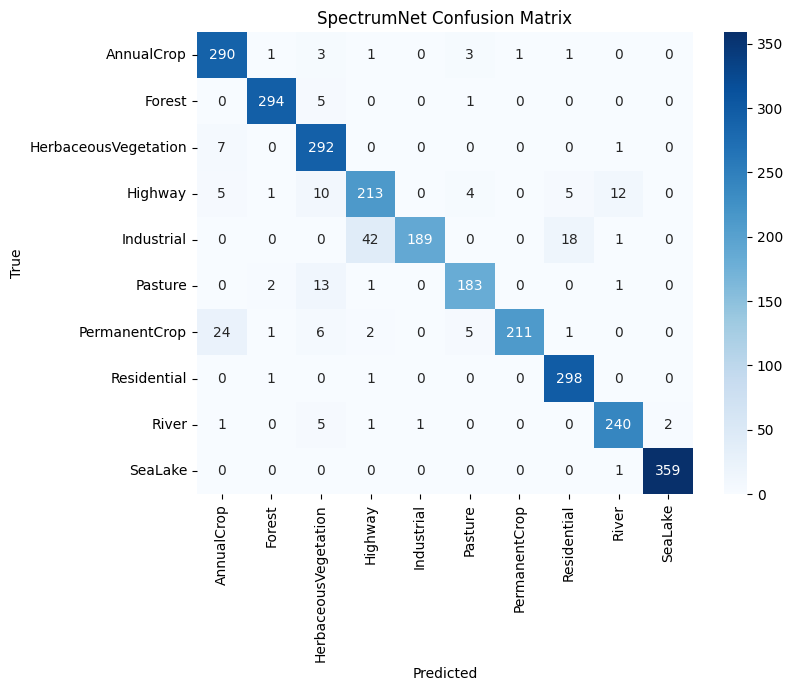

Evaluating SimpleCNN


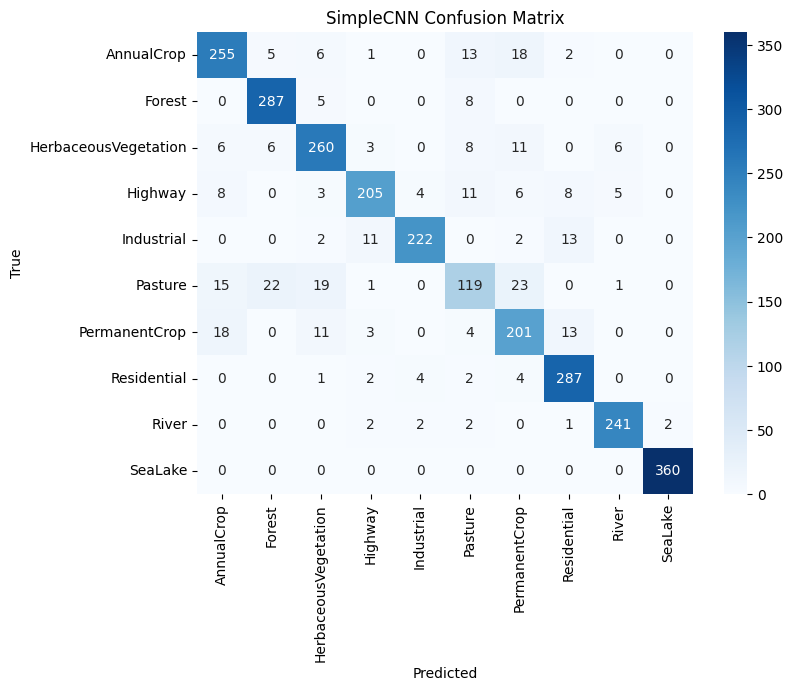

Evaluating ResNet50


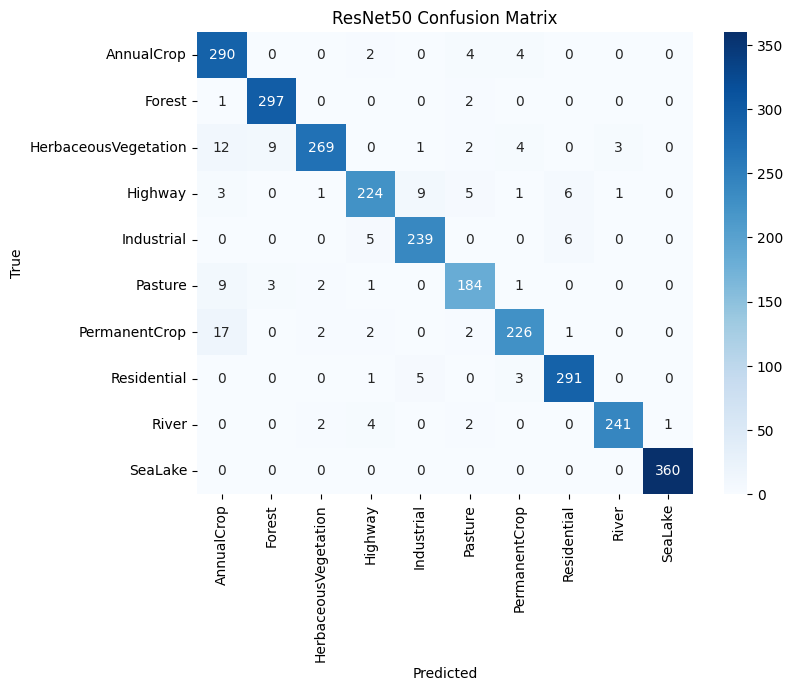

Evaluating EfficientNet


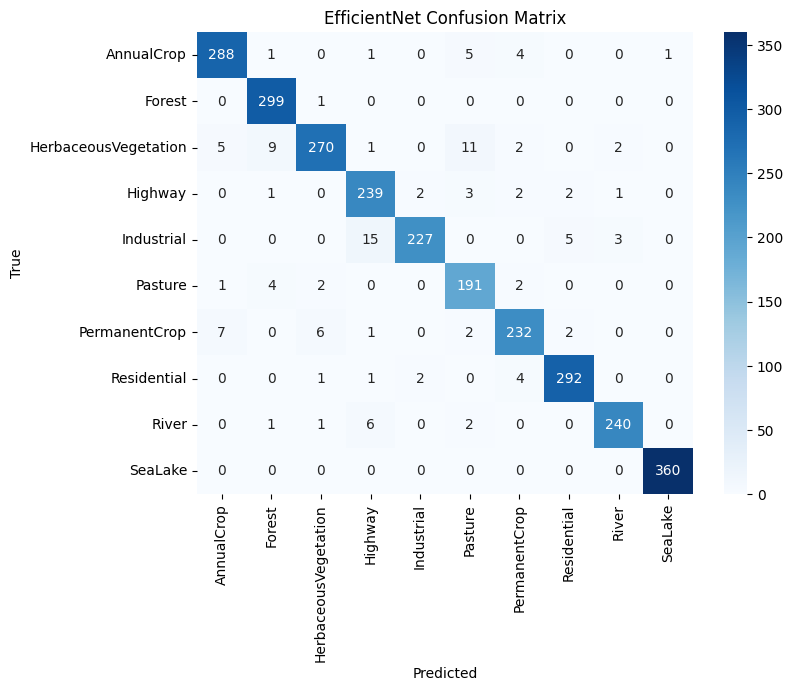

In [29]:
for name, file in models.items():

    print(f"Evaluating {name}")

    model = load_model(os.path.join(MODEL_FOLDER, file))

    pred = model.predict(X_test, verbose=0)

    y_pred = np.argmax(pred, axis=1)
    y_true = np.argmax(Y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

In [30]:
y_true = np.argmax(Y_test, axis=1)

y_test_bin = label_binarize(
    y_true,
    classes=range(len(le.classes_))
)

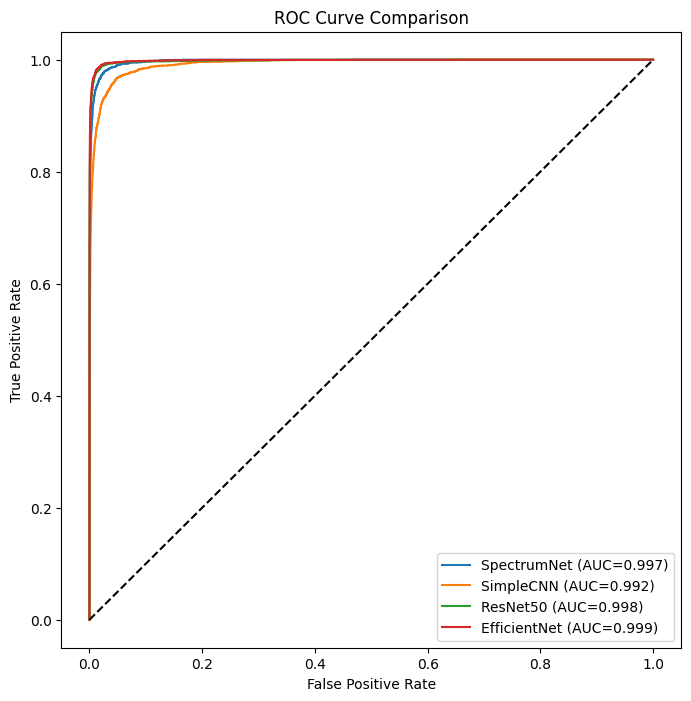

In [31]:

plt.figure(figsize=(8,8))

for name, file in models.items():

    model = load_model(os.path.join(MODEL_FOLDER, file))

    pred = model.predict(X_test, verbose=0)

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        pred.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Grad-CAM


In [32]:
image = X_test[44]
img = np.expand_dims(image, axis=0)

In [33]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [34]:
def display_gradcam(image, heatmap):

    heatmap = cv2.resize(heatmap,(64,64))

    heatmap = np.uint8(255*heatmap)

    heatmap = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)

    image = image[:,:,:3]

    image = image.astype(np.float32)

    image = (image-image.min())/(image.max()-image.min())

    image = np.uint8(255*image)

    superimposed = cv2.addWeighted(image,0.6,heatmap,0.4,0)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [35]:
index = 15

image = X_test[index]

img_array = np.expand_dims(image,axis=0)
from tensorflow.keras.models import load_model

model = load_model("SpectrumNet_final.h5")

for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

input_layer_3 InputLayer
conv2d_15 Conv2D
conv2d_16 Conv2D
conv2d_17 Conv2D
concatenate_6 Concatenate
batch_normalization_6 BatchNormalization
activation_6 Activation
add_3 Add
max_pooling2d_6 MaxPooling2D
conv2d_18 Conv2D
conv2d_19 Conv2D
concatenate_7 Concatenate
batch_normalization_7 BatchNormalization
activation_7 Activation
max_pooling2d_7 MaxPooling2D
global_average_pooling2d_3 GlobalAveragePooling2D
dense_6 Dense
dropout_3 Dropout
dense_7 Dense


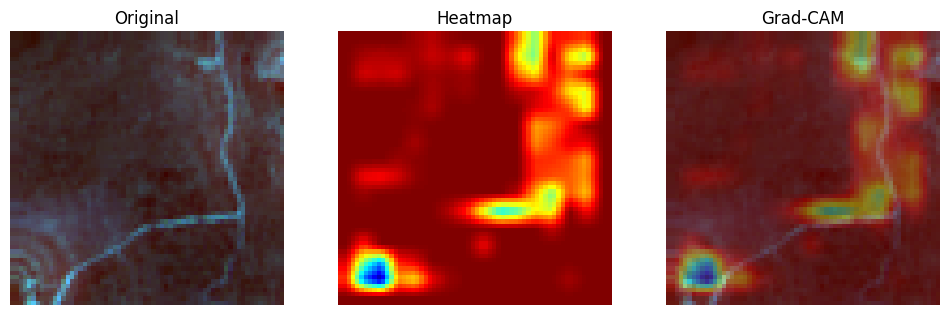

In [36]:
import cv2
last_conv_layer_name = "conv2d_19"
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

display_gradcam(image, heatmap)

## Metric table

In [37]:
results = []

for name, file in models.items():

    model = load_model(os.path.join(MODEL_FOLDER,file))

    pred = model.predict(X_test,verbose=0)

    y_pred = np.argmax(pred,axis=1)
    y_true = np.argmax(Y_test,axis=1)

    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_true,y_pred),
        "Precision":precision_score(y_true,y_pred,average="weighted"),
        "Recall":recall_score(y_true,y_pred,average="weighted"),
        "F1":f1_score(y_true,y_pred,average="weighted")
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1
0,SpectrumNet,0.930797,0.934693,0.930797,0.930036
1,SimpleCNN,0.882971,0.882059,0.882971,0.881520
2,ResNet50,0.949638,0.950693,0.949638,0.949605
3,EfficientNet,0.955797,0.956620,0.955797,0.955753
